In [30]:
# --- [TASK 2] SETUP AND PATH DEFINITION ---
from google.colab import drive
import os
import json

# Mount Google Drive
drive.mount('/content/drive')

# Path definitions
base_path = '/content/drive/MyDrive/COMP6001_Dataset'
sharp_path = os.path.join(base_path, 'val2017')
blurred_path = os.path.join(base_path, 'val2017_blurred_deterministic')
metadata_path = os.path.join(base_path, 'blur_metadata.json')

# Metadata extraction
if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        data = json.load(f)
    # Extract the nested dictionary containing image data
    metadata = data.get('transformations', {})
    print(f"Status: Metadata extracted for {len(metadata)} images.")
else:
    print(f"Error: Metadata file not found at {metadata_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Status: Metadata extracted for 5000 images.


In [31]:
# --- [TASK 2] CORE RESTORATION FUNCTIONS ---
import cv2
import numpy as np
from skimage import restoration
from scipy.ndimage import shift

def create_precise_kernel(length, angle):
    """Generate normalized linear motion blur kernel."""
    size = int(round(length))
    if size % 2 == 0: size += 1
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    # Coordinate calculation
    angle_rad = np.deg2rad(angle)
    dx = (length / 2) * np.cos(angle_rad)
    dy = (length / 2) * np.sin(angle_rad)
    p1 = (int(center - dx), int(center - dy))
    p2 = (int(center + dx), int(center + dy))

    cv2.line(kernel, p1, p2, 1.0, 1)
    return kernel / np.sum(kernel)

def restore_image(img_blurred, length, angle, balance=0.01, alignment=(-1, 0)):
    """Apply Wiener filter and spatial phase correction."""
    psf = create_precise_kernel(length, angle)
    # Wiener Deconvolution
    restored = restoration.wiener(img_blurred, psf, balance=balance)
    restored = np.clip(restored, 0, 1)
    # Vertical shift compensation
    aligned = shift(restored, alignment)
    return aligned

Status: PSNR for 000000140076.jpg is 24.39 dB


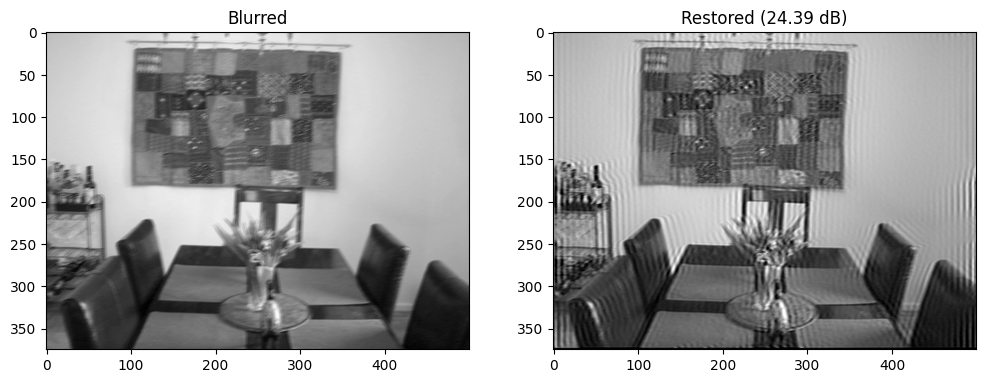

In [32]:
# --- [TASK 2] SINGLE IMAGE TEST ---
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

sample_file = '000000140076.jpg'
meta = metadata.get(sample_file)

if meta:
    # Path construction
    s_img_path = os.path.join(sharp_path, sample_file)
    b_img_path = os.path.join(blurred_path, sample_file)

    if os.path.exists(s_img_path) and os.path.exists(b_img_path):
        # Load and normalize
        img_s = cv2.imread(s_img_path, 0).astype(np.float32) / 255.0
        img_b = cv2.imread(b_img_path, 0).astype(np.float32) / 255.0

        # Restoration execution using metadata size and angle
        result = restore_image(img_b, meta['size'], meta['angle'], balance=0.01, alignment=(-1, 0))

        # Metric calculation
        psnr_final = psnr_metric(img_s, result, data_range=1.0)
        print(f"Status: PSNR for {sample_file} is {psnr_final:.2f} dB")

        # Visualization
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(img_b, cmap='gray'); plt.title("Blurred")
        plt.subplot(1, 2, 2); plt.imshow(result, cmap='gray'); plt.title(f"Restored ({psnr_final:.2f} dB)")
        plt.show()
    else:
        print(f"Error: Image files for {sample_file} missing on disk.")
else:
    print(f"Error: Metadata for {sample_file} not found in transformations.")

In [33]:
# --- [TASK 2 & 3] BATCH RESTORATION ---
from tqdm import tqdm

# Output directory setup
restored_folder = os.path.join(base_path, 'val2017_restored')
os.makedirs(restored_folder, exist_ok=True)

# Select first 20 valid filenames from the metadata dictionary
image_list = list(metadata.keys())[:20]

print("Status: Processing batch restoration...")
for filename in tqdm(image_list):
    meta = metadata[filename]

    # Path verification
    b_path = os.path.join(blurred_path, filename)
    if os.path.exists(b_path):
        img_b = cv2.imread(b_path, 0).astype(np.float32) / 255.0
        restored = restore_image(img_b, meta['size'], meta['angle'], balance=0.01, alignment=(-1, 0))

        # Save as uint8
        cv2.imwrite(os.path.join(restored_folder, filename), (restored * 255).astype(np.uint8))

print(f"Status: Batch processing complete. Target folder: {restored_folder}")

Status: Processing batch restoration...


100%|██████████| 20/20 [00:06<00:00,  2.86it/s]

Status: Batch processing complete. Target folder: /content/drive/MyDrive/COMP6001_Dataset/val2017_restored


In [35]:
# --- [TASK 3] OBJECT DETECTION INITIALIZATION ---
!pip install ultralytics -q
from ultralytics import YOLO

# Initialize the pre-trained YOLOv8 nano model
# This defines the 'detector' variable required for subsequent cells
detector = YOLO('yolov8n.pt')

print("Status: Object detection model initialized.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Status: Object detection model initialized.


In [36]:
# --- [TASK 2 & 3] PERFORMANCE SUMMARY TABLE ---
import pandas as pd
import os

results_log = []

# Ensure image_list is defined from the batch process in Cell 4
if 'image_list' in locals():
    print("Status: Generating performance summary...")

    for filename in image_list:
        blur_path = os.path.join(blurred_path, filename)
        rest_path = os.path.join(restored_folder, filename)

        # Verify both files exist before running inference
        if os.path.exists(blur_path) and os.path.exists(rest_path):
            # Run detection and count bounding boxes
            res_blur = detector(blur_path, verbose=False)[0]
            res_rest = detector(rest_path, verbose=False)[0]

            cnt_blur = len(res_blur.boxes)
            cnt_rest = len(res_rest.boxes)

            results_log.append({
                "File": filename,
                "Blur_Detections": cnt_blur,
                "Restored_Detections": cnt_rest,
                "Delta": cnt_rest - cnt_blur
            })

    # Generate and display the summary table
    if results_log:
        df = pd.DataFrame(results_log)
        print("\n--- PERFORMANCE SUMMARY ---")
        print(df)
        print("\nMean Detections (Blurred):", round(df['Blur_Detections'].mean(), 2))
        print("Mean Detections (Restored):", round(df['Restored_Detections'].mean(), 2))
    else:
        print("Error: No processed images found for evaluation.")
else:
    print("Error: 'image_list' not found. Run the Batch Restoration cell first.")

Status: Generating performance summary...

--- PERFORMANCE SUMMARY ---
                File  Blur_Detections  Restored_Detections  Delta
0   000000000139.jpg                5                    3     -2
1   000000000285.jpg                1                    1      0
2   000000000632.jpg                1                    0     -1
3   000000000724.jpg                1                    0     -1
4   000000000776.jpg                1                    2      1
5   000000000785.jpg                1                    3      2
6   000000000802.jpg                2                    0     -2
7   000000000872.jpg                2                    0     -2
8   000000000885.jpg                7                    3     -4
9   000000001000.jpg                9                   10      1
10  000000001268.jpg                6                    4     -2
11  000000001296.jpg                1                    1      0
12  000000001353.jpg                2                    1     -1
13  0

**UPDATING and implementing changes ->**

In [38]:
# --- [TASK 2 & 3] UPDATED BATCH RESTORATION ---
from tqdm import tqdm

# Apply the successful parameter from the refined test
optimal_balance = 0.05
restored_folder = os.path.join(base_path, 'val2017_restored')
os.makedirs(restored_folder, exist_ok=True)

# Process the subset of 20 images
image_list = list(metadata.keys())[:20]

print(f"Status: Processing batch with balance {optimal_balance}...")
for filename in tqdm(image_list):
    meta = metadata[filename]
    b_path = os.path.join(blurred_path, filename)

    if os.path.exists(b_path):
        img_b = cv2.imread(b_path, 0).astype(np.float32) / 255.0

        # Restore using the refined balance
        restored = restore_image(img_b, meta['size'], meta['angle'],
                                   balance=optimal_balance, alignment=(-1, 0))

        # Save for detection
        cv2.imwrite(os.path.join(restored_folder, filename), (restored * 255).astype(np.uint8))

print("Status: Batch processing complete.")

Status: Processing batch with balance 0.05...


100%|██████████| 20/20 [00:05<00:00,  3.63it/s]

Status: Batch processing complete.


In [39]:
# --- [TASK 3] UPDATED PERFORMANCE SUMMARY ---
import pandas as pd

results_log = []

print("Status: Generating final performance summary...")
for filename in image_list:
    blur_path = os.path.join(blurred_path, filename)
    rest_path = os.path.join(restored_folder, filename)

    if os.path.exists(blur_path) and os.path.exists(rest_path):
        res_blur = detector(blur_path, verbose=False)[0]
        res_rest = detector(rest_path, verbose=False)[0]

        results_log.append({
            "File": filename,
            "Blur_Detections": len(res_blur.boxes),
            "Restored_Detections": len(res_rest.boxes),
            "Delta": len(res_rest.boxes) - len(res_blur.boxes)
        })

df_final = pd.DataFrame(results_log)
print("\n--- FINAL PERFORMANCE SUMMARY ---")
print(df_final)
print("\nMean Detections (Blurred):", round(df_final['Blur_Detections'].mean(), 2))
print("Mean Detections (Restored):", round(df_final['Restored_Detections'].mean(), 2))

Status: Generating final performance summary...

--- FINAL PERFORMANCE SUMMARY ---
                File  Blur_Detections  Restored_Detections  Delta
0   000000000139.jpg                5                    4     -1
1   000000000285.jpg                1                    1      0
2   000000000632.jpg                1                    2      1
3   000000000724.jpg                1                    0     -1
4   000000000776.jpg                1                    2      1
5   000000000785.jpg                1                    2      1
6   000000000802.jpg                2                    0     -2
7   000000000872.jpg                2                    2      0
8   000000000885.jpg                7                    2     -5
9   000000001000.jpg                9                    9      0
10  000000001268.jpg                6                    7      1
11  000000001296.jpg                1                    1      0
12  000000001353.jpg                2                    1 